In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('outputs', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style="whitegrid")

print("✅ Setup complete")

✅ Setup complete


In [2]:
df = pd.read_csv('customer_data.csv', parse_dates=['join_date', 'churn_date'])

# Feature engineering
df['is_churned']     = df['status'] == 'Churned'
df['join_month']     = df['join_date'].dt.to_period('M')
df['join_yearmonth'] = df['join_date'].dt.strftime('%Y-%m')
df['churn_month']    = df['churn_date'].dt.to_period('M')
df['clv']            = df['monthly_charge'] * df['tenure_months']

print(f"Total customers : {len(df)}")
print(f"Churned         : {df['is_churned'].sum()}")
print(f"Active          : {(~df['is_churned']).sum()}")
print(f"Overall churn % : {df['is_churned'].mean()*100:.1f}%")
df.head()

Total customers : 50
Churned         : 22
Active          : 28
Overall churn % : 44.0%


,customer_id,join_date,churn_date,status,age,gender,plan,monthly_charge,tenure_months,support_tickets,last_login_days,region,referral,is_churned,join_month,join_yearmonth,churn_month,clv
0,C001,2023-01-05,2023-07-15,Churned,34,Male,Basic,29,6,3,45,North,No,True,2023-01,2023-01,2023-07,174
1,C002,2023-01-10,NaT,Active,28,Female,Premium,79,17,1,2,East,Yes,False,2023-01,2023-01,NaT,1343
2,C003,2023-02-01,2023-08-20,Churned,45,Male,Standard,49,6,5,60,West,No,True,2023-02,2023-02,2023-08,294
3,C004,2023-02-14,NaT,Active,52,Female,Premium,79,16,0,5,South,Yes,False,2023-02,2023-02,NaT,1264
4,C005,2023-03-01,2023-06-30,Churned,23,Male,Basic,29,3,7,90,North,No,True,2023-03,2023-03,2023-06,87


In [3]:
total      = len(df)
churned    = df['is_churned'].sum()
active     = total - churned
churn_rate = churned / total * 100
avg_tenure = df['tenure_months'].mean()
avg_clv    = df['clv'].mean()
avg_charge = df['monthly_charge'].mean()

print("=" * 45)
print("     CUSTOMER RETENTION KPI SUMMARY")
print("=" * 45)
print(f"  Total Customers    : {total}")
print(f"  Active Customers   : {active}")
print(f"  Churned Customers  : {churned}")
print(f"  Churn Rate         : {churn_rate:.1f}%")
print(f"  Avg Tenure         : {avg_tenure:.1f} months")
print(f"  Avg CLV            : ${avg_clv:.0f}")
print(f"  Avg Monthly Charge : ${avg_charge:.0f}")
print("=" * 45)

     CUSTOMER RETENTION KPI SUMMARY
  Total Customers    : 50
  Active Customers   : 28
  Churned Customers  : 22
  Churn Rate         : 44.0%
  Avg Tenure         : 6.9 months
  Avg CLV            : $376
  Avg Monthly Charge : $51


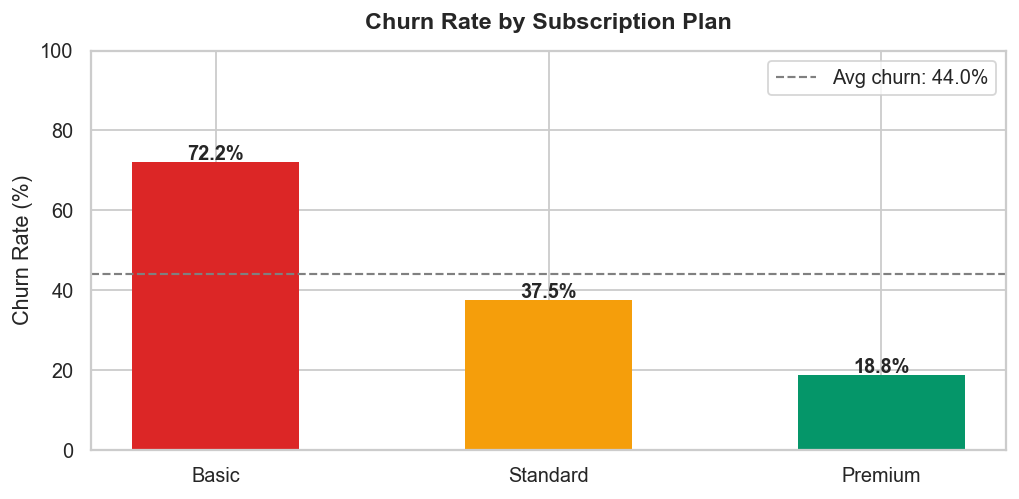

✅ Saved: 01_churn_by_plan.png


In [4]:
plan_churn = df.groupby('plan')['is_churned'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#DC2626' if v > 40 else '#F59E0B' if v > 20 else '#059669'
          for v in plan_churn.values]
bars = ax.bar(plan_churn.index, plan_churn.values,
              color=colors, width=0.5, edgecolor='none')

for bar, val in zip(bars, plan_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.1f}%", ha='center', fontsize=11, fontweight='bold')

ax.axhline(churn_rate, color='gray', linestyle='--', linewidth=1.2, label=f'Avg churn: {churn_rate:.1f}%')
ax.set_title("Churn Rate by Subscription Plan", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('outputs/01_churn_by_plan.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 01_churn_by_plan.png")

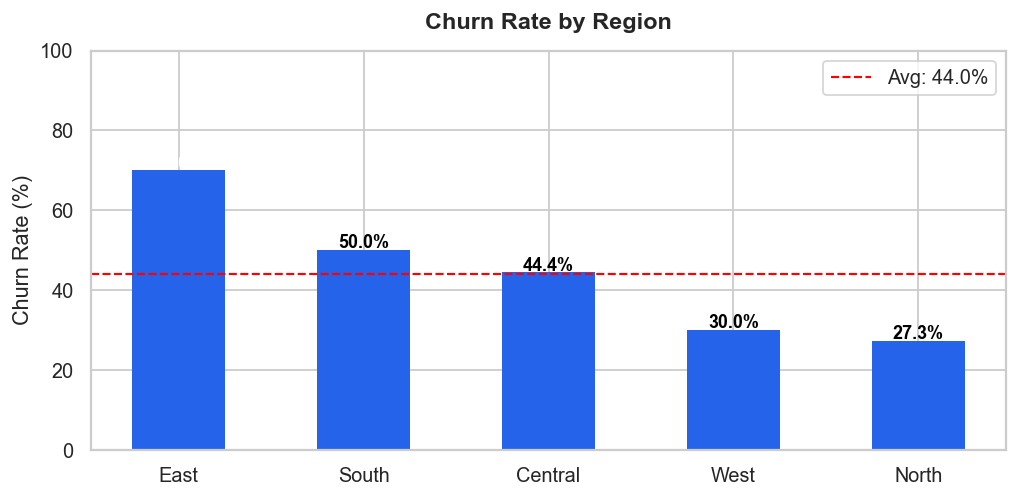

✅ Saved: 02_churn_by_region.png


In [5]:
reg_churn = df.groupby('region')['is_churned'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(reg_churn.index, reg_churn.values,
              color='#2563EB', width=0.5, edgecolor='none')
for bar, val in zip(bars, reg_churn.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.5,
            f"{val:.1f}%", ha='center', fontsize=10, fontweight='bold', color='white' if val > 50 else 'black')

ax.axhline(churn_rate, color='red', linestyle='--', linewidth=1.2, label=f'Avg: {churn_rate:.1f}%')
ax.set_title("Churn Rate by Region", fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.savefig('outputs/02_churn_by_region.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 02_churn_by_region.png")

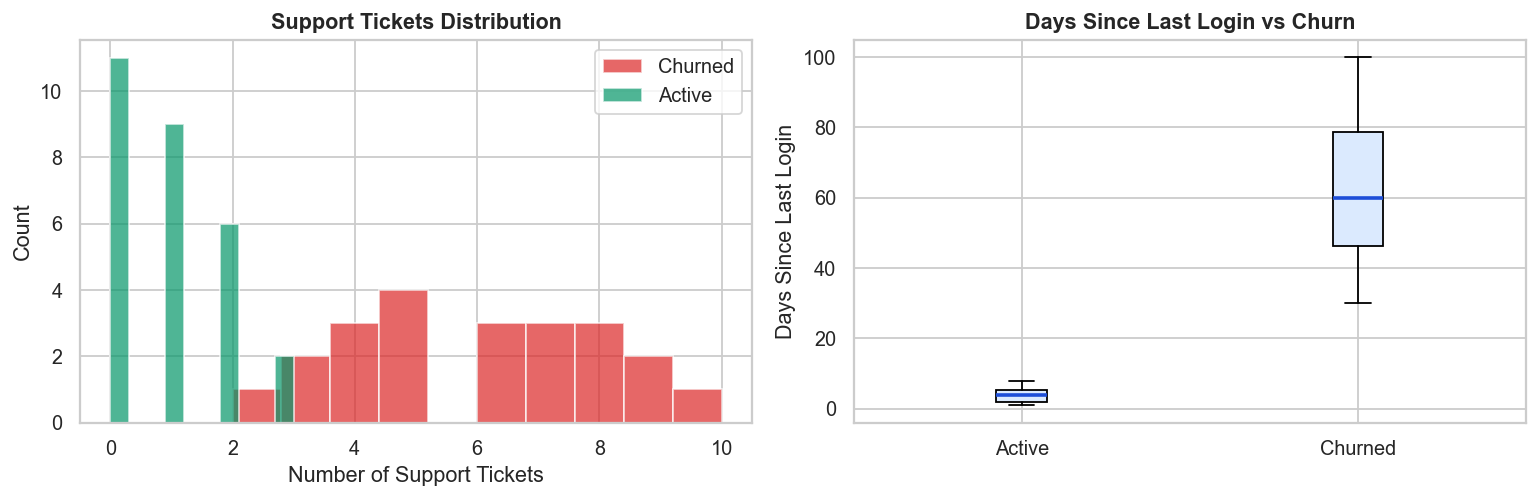

✅ Saved: 03_churn_drivers.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Support tickets distribution
churned_tickets = df[df['is_churned']]['support_tickets']
active_tickets  = df[~df['is_churned']]['support_tickets']
axes[0].hist(churned_tickets, bins=10, alpha=0.7, color='#DC2626', label='Churned', edgecolor='white')
axes[0].hist(active_tickets,  bins=10, alpha=0.7, color='#059669', label='Active',  edgecolor='white')
axes[0].set_title("Support Tickets Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Number of Support Tickets")
axes[0].set_ylabel("Count")
axes[0].legend()

# Last login days vs churn
churned_login = df[df['is_churned']]['last_login_days']
active_login  = df[~df['is_churned']]['last_login_days']
axes[1].boxplot([active_login, churned_login], labels=['Active', 'Churned'],
                patch_artist=True,
                boxprops=dict(facecolor='#DBEAFE'),
                medianprops=dict(color='#1D4ED8', linewidth=2))
axes[1].set_title("Days Since Last Login vs Churn", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Days Since Last Login")

plt.tight_layout()
plt.savefig('outputs/03_churn_drivers.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 03_churn_drivers.png")

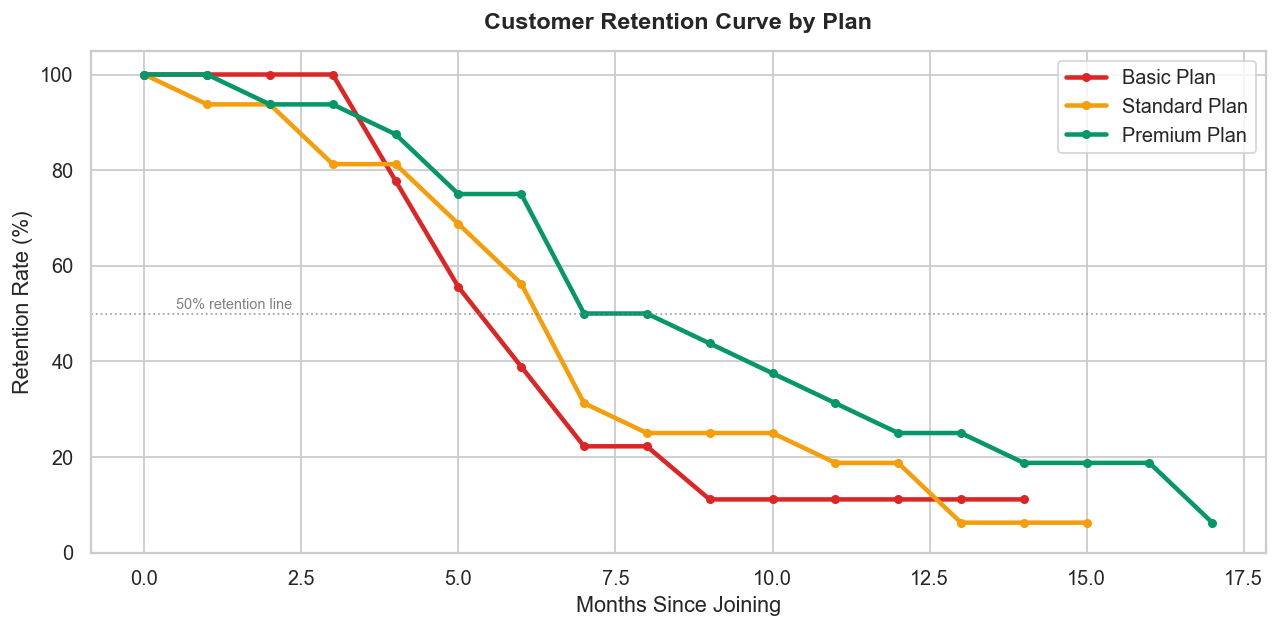

✅ Saved: 04_retention_curve.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
plan_colors = {'Basic': '#DC2626', 'Standard': '#F59E0B', 'Premium': '#059669'}

for plan, color in plan_colors.items():
    plan_df = df[df['plan'] == plan].copy()
    max_tenure = int(plan_df['tenure_months'].max()) + 1
    months = range(0, max_tenure)
    retention = []
    for m in months:
        survived = (plan_df['tenure_months'] >= m).sum()
        retention.append(survived / len(plan_df) * 100)
    ax.plot(list(months), retention, color=color, linewidth=2.5,
            marker='o', markersize=4, label=f'{plan} Plan')

ax.set_title("Customer Retention Curve by Plan", fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Months Since Joining")
ax.set_ylabel("Retention Rate (%)")
ax.set_ylim(0, 105)
ax.legend()
ax.axhline(50, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.text(0.5, 51, '50% retention line', fontsize=8, color='gray')
plt.tight_layout()
plt.savefig('outputs/04_retention_curve.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 04_retention_curve.png")

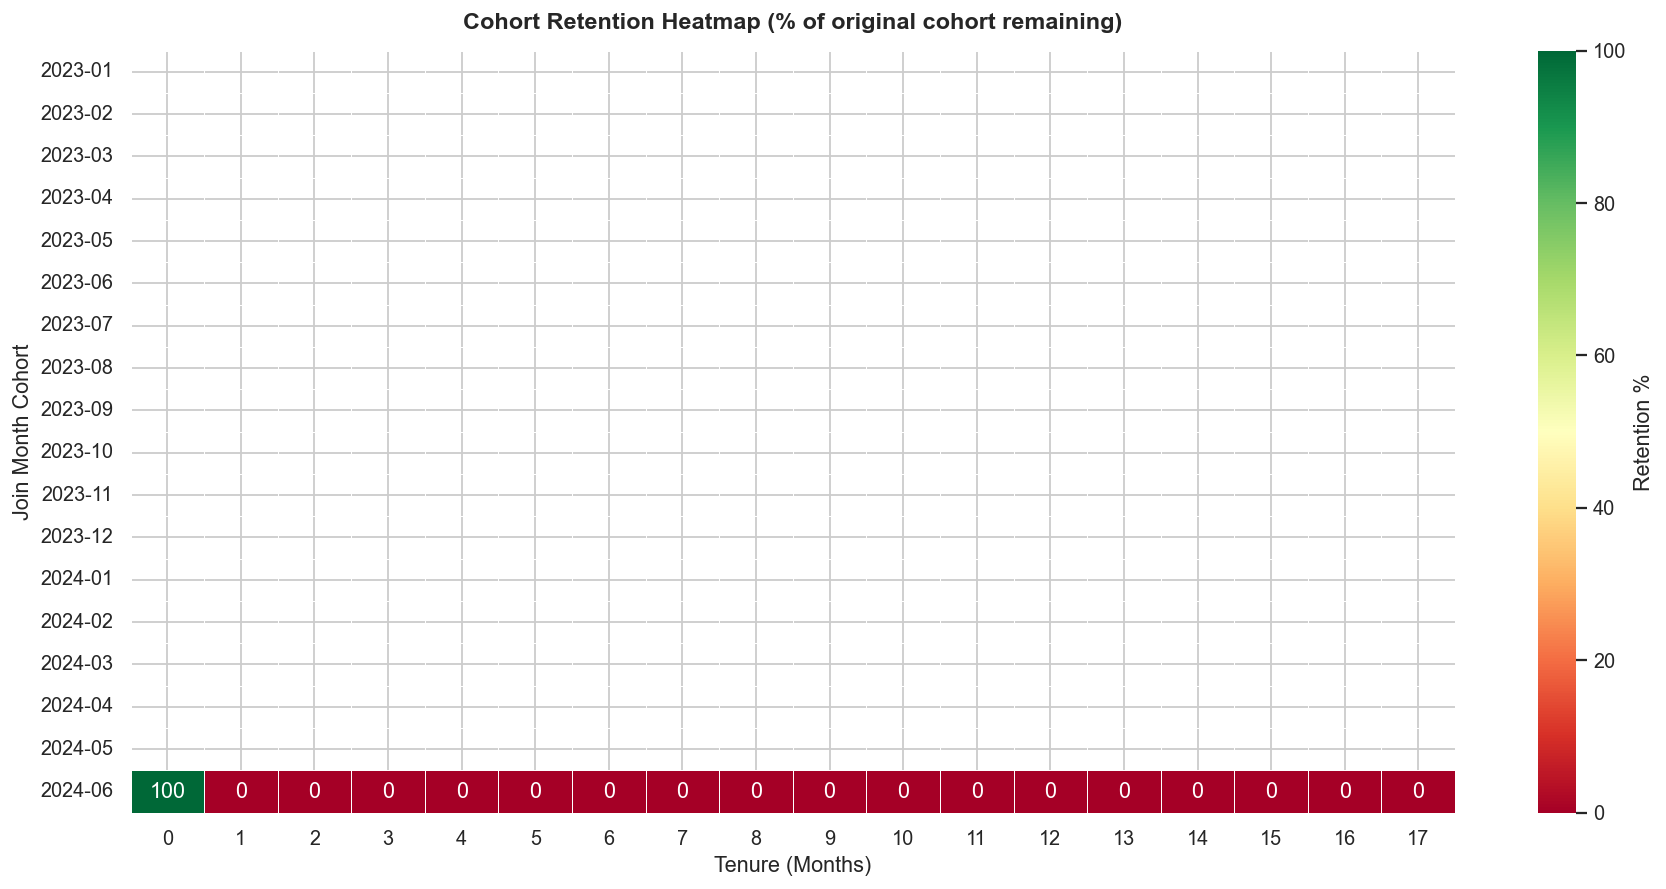

✅ Saved: 05_cohort_heatmap.png


In [8]:
cohort = df.groupby(['join_yearmonth', 'tenure_months']).size().unstack(fill_value=0)
cohort_pct = cohort.div(cohort.iloc[:, 0], axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cohort_pct, annot=True, fmt='.0f', cmap='RdYlGn',
            linewidths=0.5, linecolor='white', ax=ax,
            vmin=0, vmax=100,
            cbar_kws={'label': 'Retention %'})
ax.set_title("Cohort Retention Heatmap (% of original cohort remaining)",
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel("Tenure (Months)")
ax.set_ylabel("Join Month Cohort")
plt.tight_layout()
plt.savefig('outputs/05_cohort_heatmap.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 05_cohort_heatmap.png")

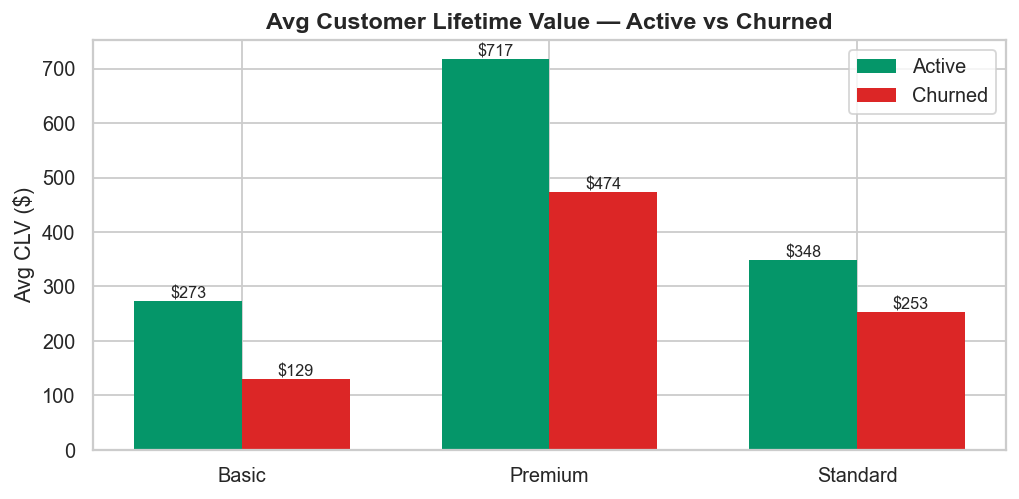

✅ Saved: 06_clv_comparison.png


In [9]:
clv_plan = df.groupby(['plan', 'status'])['clv'].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(clv_plan.index))
width = 0.35
bars1 = ax.bar(x - width/2, clv_plan.get('Active', 0),  width, label='Active',  color='#059669', edgecolor='none')
bars2 = ax.bar(x + width/2, clv_plan.get('Churned', 0), width, label='Churned', color='#DC2626', edgecolor='none')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"${bar.get_height():.0f}", ha='center', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"${bar.get_height():.0f}", ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(clv_plan.index)
ax.set_title("Avg Customer Lifetime Value — Active vs Churned", fontsize=13, fontweight='bold')
ax.set_ylabel("Avg CLV ($)")
ax.legend()
plt.tight_layout()
plt.savefig('outputs/06_clv_comparison.png', bbox_inches='tight')
plt.show()
print("✅ Saved: 06_clv_comparison.png")

In [10]:
summary = df.groupby('plan').agg(
    Total_Customers=('customer_id', 'count'),
    Churned=('is_churned', 'sum'),
    Churn_Rate=('is_churned', lambda x: f"{x.mean()*100:.1f}%"),
    Avg_Tenure=('tenure_months', lambda x: f"{x.mean():.1f} mo"),
    Avg_CLV=('clv', lambda x: f"${x.mean():.0f}"),
    Avg_Monthly=('monthly_charge', lambda x: f"${x.mean():.0f}")
)

print("\n📊 Plan-wise Retention Summary\n")
print(summary.to_string())
summary.to_csv('outputs/retention_summary.csv')
print("\n✅ Saved: retention_summary.csv")


📊 Plan-wise Retention Summary

          Total_Customers  Churned Churn_Rate Avg_Tenure Avg_CLV Avg_Monthly
plan                                                                        
Basic                  18       13      72.2%     5.8 mo    $169         $29
Premium                16        3      18.8%     8.5 mo    $672         $79
Standard               16        6      37.5%     6.4 mo    $312         $49

✅ Saved: retention_summary.csv
